In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold

from xgboost import XGBRegressor

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
column_names = ["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6", "y"]

df = pd.read_csv(
    "https://web.stanford.edu/~hastie/Papers/LARS/diabetes.data",
    sep=r"\s+",
    header=0,
    names=column_names
)

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (442, 11)


In [4]:
print("Columns:")
print(df.columns.tolist())

Columns:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'y']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    int64  
 1   sex     442 non-null    int64  
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    int64  
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    int64  
 10  y       442 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 38.1 KB


In [6]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,y
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


In [7]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


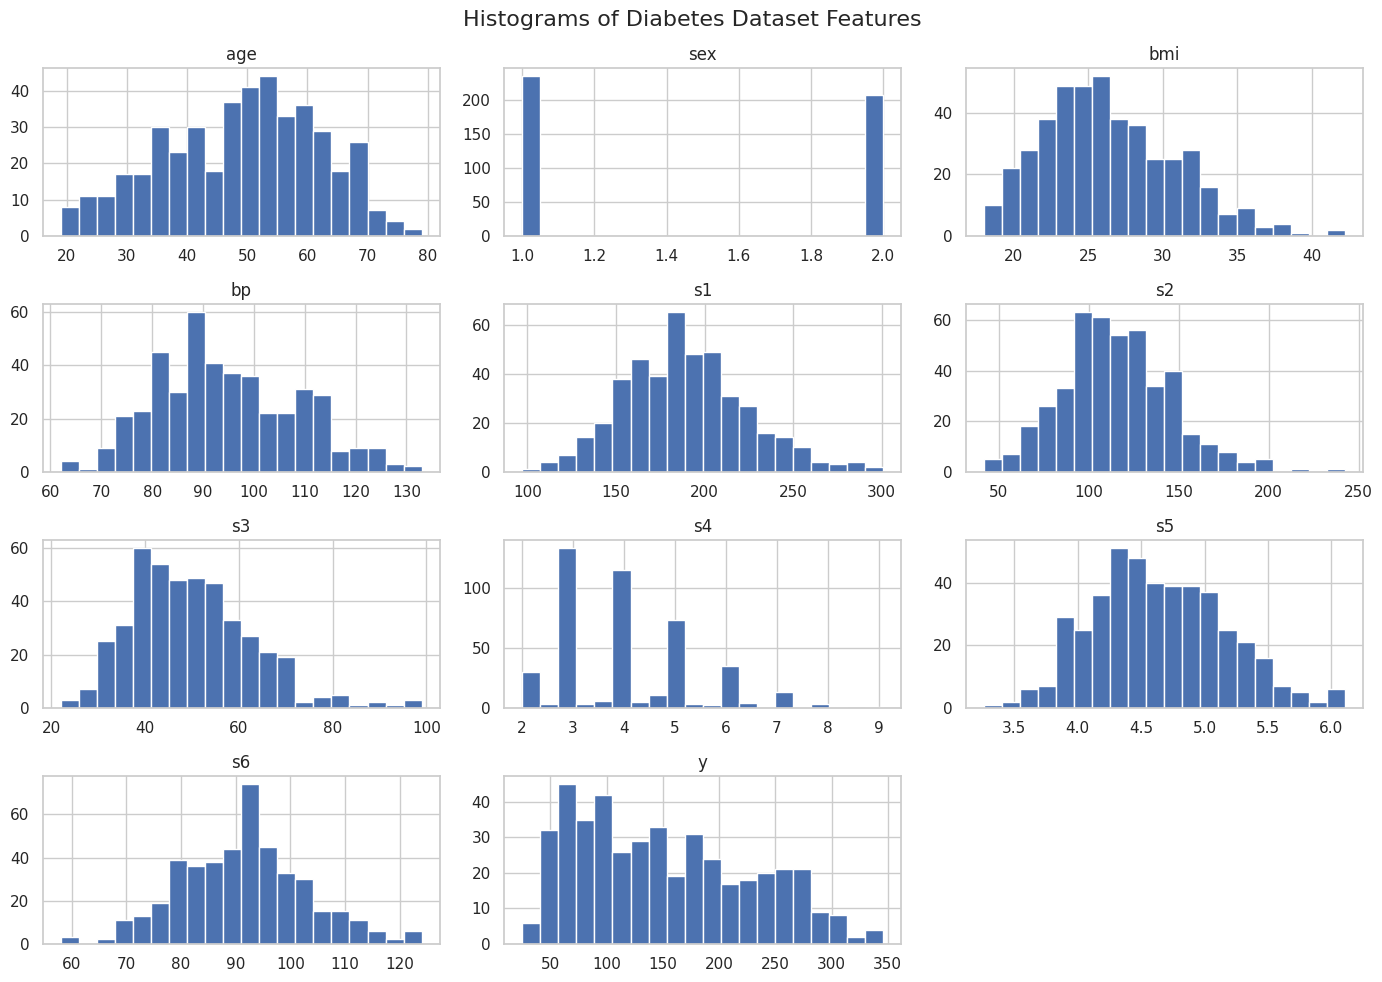

In [8]:
df.hist(figsize=(14, 10), bins=20)
plt.suptitle("Histograms of Diabetes Dataset Features", fontsize=16)
plt.tight_layout()
plt.show()

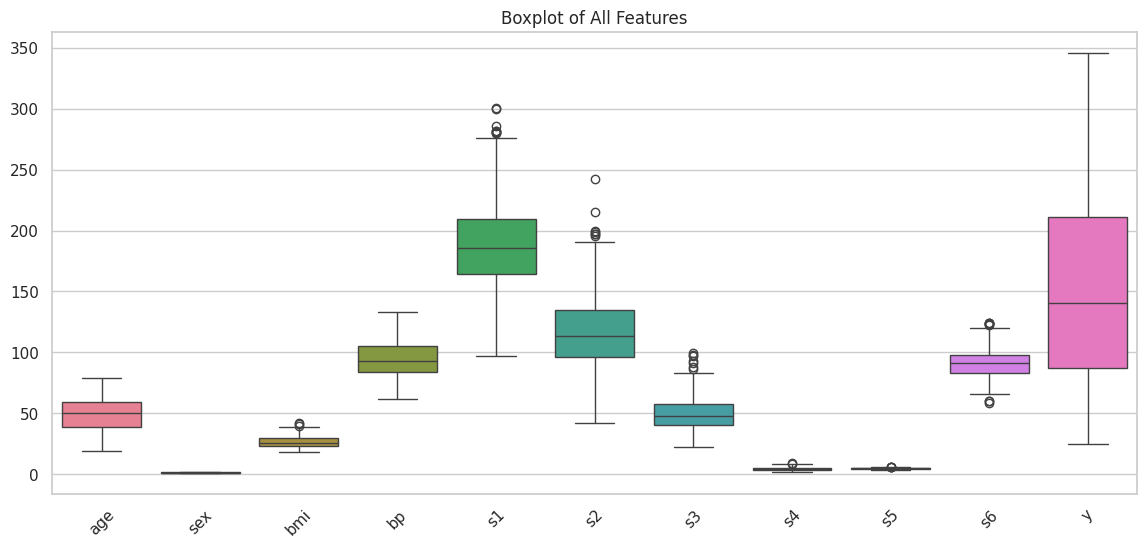

In [9]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot of All Features")
plt.show()

In [10]:
corr_matrix = df.corr()
corr_matrix

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,y
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


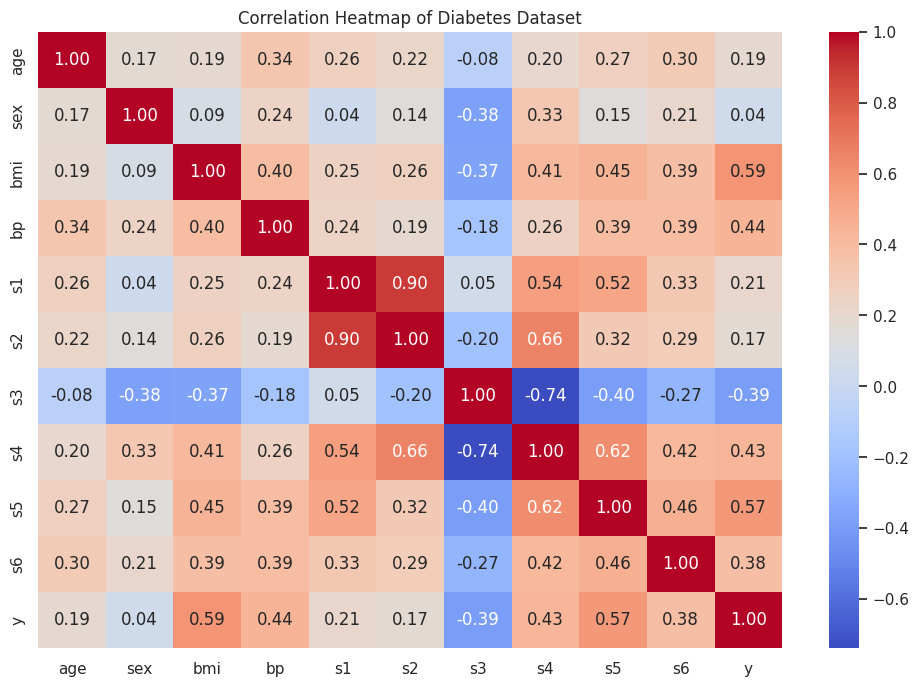

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Diabetes Dataset")
plt.show()

In [12]:
target_corr = corr_matrix["y"].drop("y").sort_values(key=abs, ascending=False)
target_corr

,y
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s3,-0.394789
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


In [13]:
X = df.drop(columns=["y"])
y = df["y"]

In [14]:
single_feature_results = []

for feature in X.columns:
    X_single = X[[feature]]
    model = LinearRegression()
    model.fit(X_single, y)
    y_pred = model.predict(X_single)
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    single_feature_results.append({
        "Feature": feature,
        "Slope": model.coef_[0],
        "Intercept": model.intercept_,
        "MSE": mse,
        "R2": r2
    })

single_feature_df = pd.DataFrame(single_feature_results).sort_values(by="MSE")
single_feature_df

,Feature,Slope,Intercept,MSE,R2
2,bmi,10.233128,-117.773367,3890.456585,0.343924
8,s5,83.511442,-235.477432,4030.998723,0.320223
3,bp,2.460737,-80.767954,4774.113902,0.194906
7,s4,25.715765,47.463921,4831.138386,0.185290
6,s3,-2.353101,269.290784,5005.661621,0.155859
9,s6,2.564887,-81.938579,5062.380595,0.146294
4,s1,0.472302,62.802166,5663.315624,0.044954
0,age,1.104957,98.523084,5720.547017,0.035302
5,s2,0.441202,101.201498,5750.241103,0.030295
1,sex,6.645390,142.375887,5918.888900,0.001854


In [15]:
best_single = single_feature_df.iloc[0]
best_single_feature = best_single["Feature"]

best_single

,2
Feature,bmi
Slope,10.233128
Intercept,-117.773367
MSE,3890.456585
R2,0.343924


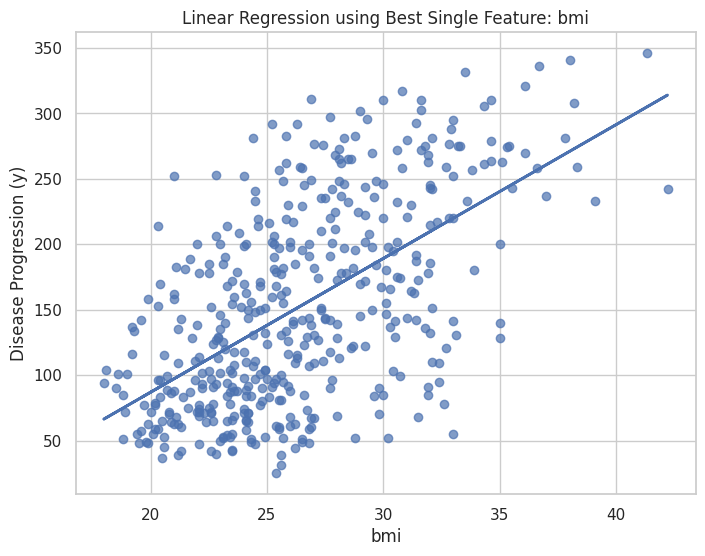

In [16]:
X_best_single = X[[best_single_feature]]

model_single = LinearRegression()
model_single.fit(X_best_single, y)
y_pred_single = model_single.predict(X_best_single)

plt.figure(figsize=(8, 6))
plt.scatter(X_best_single, y, alpha=0.7)
plt.plot(X_best_single, y_pred_single, linewidth=2)
plt.xlabel(best_single_feature)
plt.ylabel("Disease Progression (y)")
plt.title(f"Linear Regression using Best Single Feature: {best_single_feature}")
plt.show()

In [17]:
print(f"Best Single Feature : {best_single_feature}")
print(f"Slope (Coefficient) : {model_single.coef_[0]:.4f}")
print(f"Intercept           : {model_single.intercept_:.4f}")
print(f"MSE                 : {best_single['MSE']:.4f}")

Best Single Feature : bmi
Slope (Coefficient) : 10.2331
Intercept           : -117.7734
MSE                 : 3890.4566


In [18]:
pair_results = []

for pair in combinations(X.columns, 2):
    X_pair = X[list(pair)]
    model = LinearRegression()
    model.fit(X_pair, y)
    y_pred = model.predict(X_pair)
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    pair_results.append({
        "Feature 1": pair[0],
        "Feature 2": pair[1],
        "Intercept": model.intercept_,
        "Coefficient 1": model.coef_[0],
        "Coefficient 2": model.coef_[1],
        "MSE": mse,
        "R2": r2
    })

pair_feature_df = pd.DataFrame(pair_results).sort_values(by="MSE")
pair_feature_df.head(10)

,Feature 1,Feature 2,Intercept,Coefficient 1,Coefficient 2,MSE,R2
22,bmi,s5,-299.957515,7.276001,56.056387,3205.190077,0.459485
17,bmi,bp,-203.623268,8.519012,1.384735,3581.685006,0.395994
21,bmi,s4,-129.716464,8.597126,13.535767,3638.169361,0.386469
20,bmi,s3,-21.116064,8.904326,-1.237417,3669.264492,0.381225
28,bp,s5,-302.280699,1.443079,68.477251,3695.054342,0.376876
23,bmi,s6,-196.615458,8.998474,1.220763,3723.628636,0.372057
40,s3,s5,-120.836238,-1.199266,71.676333,3829.072525,0.354275
1,age,bmi,-134.217551,0.483177,9.967783,3851.799195,0.350443
18,bmi,s1,-139.189266,9.928467,0.155713,3863.289523,0.348505
19,bmi,s2,-121.639017,10.130956,0.056831,3887.679278,0.344392


In [19]:
best_pair = pair_feature_df.iloc[0]
best_pair

,22
Feature 1,bmi
Feature 2,s5
Intercept,-299.957515
Coefficient 1,7.276001
Coefficient 2,56.056387
MSE,3205.190077
R2,0.459485


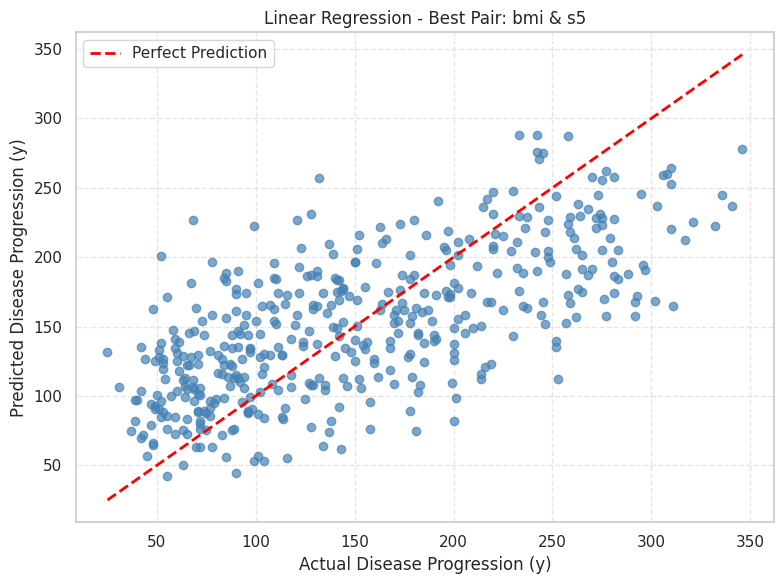

Best Pair Features : bmi & s5
Intercept          : -299.9575
Coefficient [bmi] : 7.2760
Coefficient [s5] : 56.0564
MSE                : 3205.1901


In [20]:
# Fit the best pair model
best_pair_features = [best_pair["Feature 1"], best_pair["Feature 2"]]
X_best_pair = X[best_pair_features]

model_pair = LinearRegression()
model_pair.fit(X_best_pair, y)
y_pred_pair = model_pair.predict(X_best_pair)

# Plot predicted vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_pair, alpha=0.7, color="steelblue")
plt.plot([y.min(), y.max()], [y.min(), y.max()],
         color="red", linewidth=2, linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual Disease Progression (y)")
plt.ylabel("Predicted Disease Progression (y)")
plt.title(f"Linear Regression - Best Pair: {best_pair_features[0]} & {best_pair_features[1]}")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Best Pair Features : {best_pair_features[0]} & {best_pair_features[1]}")
print(f"Intercept          : {model_pair.intercept_:.4f}")
print(f"Coefficient [{best_pair_features[0]}] : {model_pair.coef_[0]:.4f}")
print(f"Coefficient [{best_pair_features[1]}] : {model_pair.coef_[1]:.4f}")
print(f"MSE                : {best_pair['MSE']:.4f}")

In [21]:
model_all = LinearRegression()
model_all.fit(X, y)
y_pred_all = model_all.predict(X)

all_features_mse = mean_squared_error(y, y_pred_all)
all_features_r2 = r2_score(y, y_pred_all)

all_results = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_all.coef_
})

all_results

,Feature,Coefficient
0,age,-0.036361
1,sex,-22.859648
2,bmi,5.602962
3,bp,1.116808
4,s1,-1.089996
5,s2,0.746450
6,s3,0.372005
7,s4,6.533832
8,s5,68.483125
9,s6,0.280117


In [22]:
print("=== All Features Linear Regression ===")
print(f"Intercept : {model_all.intercept_:.4f}")
print(f"MSE       : {all_features_mse:.4f}")
print(f"R²        : {all_features_r2:.4f}")
print("\nCoefficients:")
for feat, coef in zip(X.columns, model_all.coef_):
    print(f"  {feat:>5} : {coef:.4f}")

=== All Features Linear Regression ===
Intercept : -334.5671
MSE       : 2859.6963
R²        : 0.5177

Coefficients:
    age : -0.0364
    sex : -22.8596
    bmi : 5.6030
     bp : 1.1168
     s1 : -1.0900
     s2 : 0.7465
     s3 : 0.3720
     s4 : 6.5338
     s5 : 68.4831
     s6 : 0.2801


In [23]:
train_sizes = [20, 50, 100, 200]
mse_results = []

for size in train_sizes:
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, train_size=size, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_mse = mean_squared_error(y_train, train_pred)
    val_mse = mean_squared_error(y_val, val_pred)

    mse_results.append({
        "Training Size": size,
        "Training MSE": train_mse,
        "Validation MSE": val_mse
    })

mse_df = pd.DataFrame(mse_results)
mse_df

,Training Size,Training MSE,Validation MSE
0,20,2066.506296,15905.595733
1,50,2863.615195,3907.016929
2,100,3150.514574,3423.446160
3,200,2854.949839,3014.919458


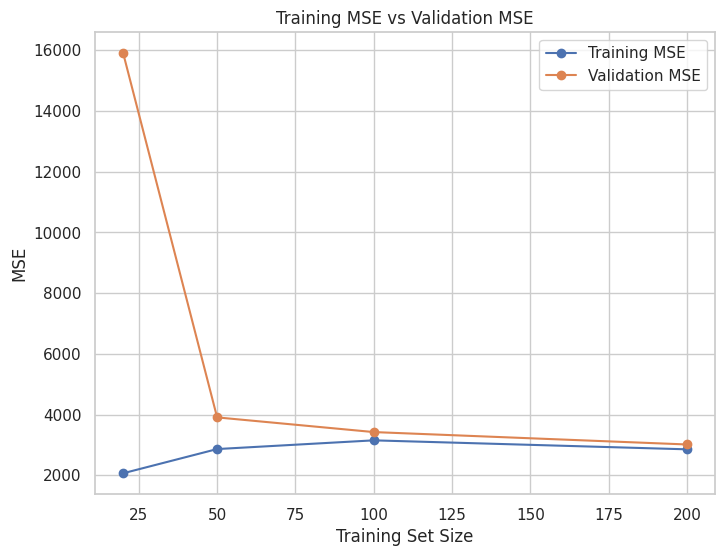

In [24]:
plt.figure(figsize=(8, 6))
plt.plot(mse_df["Training Size"], mse_df["Training MSE"], marker="o", label="Training MSE")
plt.plot(mse_df["Training Size"], mse_df["Validation MSE"], marker="o", label="Validation MSE")
plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.title("Training MSE vs Validation MSE")
plt.legend()
plt.show()

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
lr_test_model = LinearRegression()
lr_test_model.fit(X_train, y_train)

y_pred_lr_test = lr_test_model.predict(X_test)

lr_test_mse = mean_squared_error(y_test, y_pred_lr_test)
lr_test_r2 = r2_score(y_test, y_pred_lr_test)

lr_test_mse, lr_test_r2

(2900.193628493482, 0.4526027629719195)

In [27]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb_test = xgb_model.predict(X_test)

xgb_test_mse = mean_squared_error(y_test, y_pred_xgb_test)
xgb_test_r2 = r2_score(y_test, y_pred_xgb_test)

xgb_test_mse, xgb_test_r2

(2959.4560546875, 0.44141727685928345)

In [28]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost"],
    "Test MSE": [lr_test_mse, xgb_test_mse],
    "Test R2": [lr_test_r2, xgb_test_r2]
})

comparison_df

,Model,Test MSE,Test R2
0,Linear Regression,2900.193628,0.452603
1,XGBoost,2959.456055,0.441417


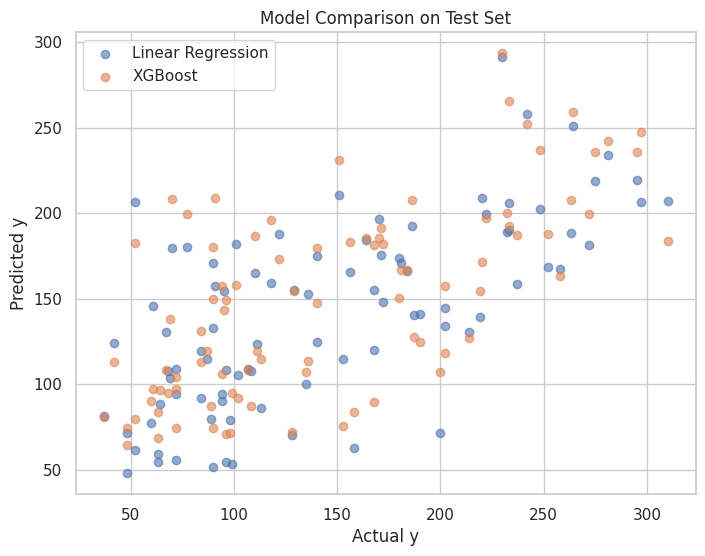

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr_test, alpha=0.6, label="Linear Regression")
plt.scatter(y_test, y_pred_xgb_test, alpha=0.6, label="XGBoost")
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Model Comparison on Test Set")
plt.legend()
plt.show()

In [30]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
2,bmi,0.316718
8,s5,0.216730
3,bp,0.086361
6,s3,0.067688
7,s4,0.066521
9,s6,0.064501
4,s1,0.050227
1,sex,0.050042
5,s2,0.045142
0,age,0.036071


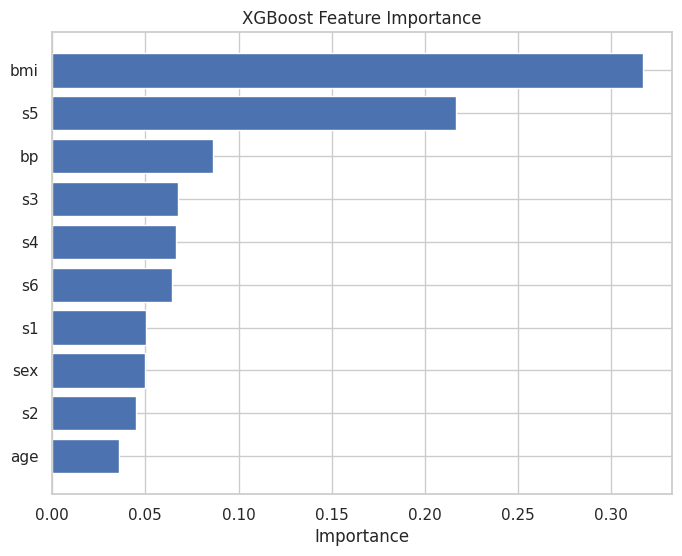

In [31]:
plt.figure(figsize=(8, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

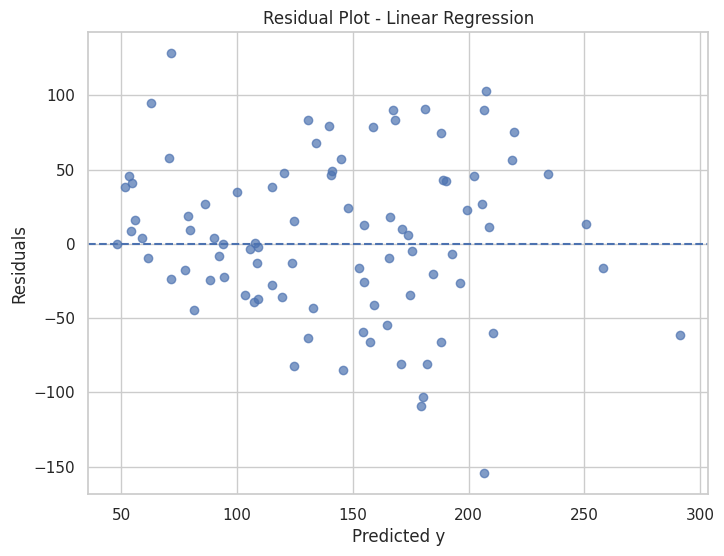

In [32]:
residuals_lr = y_test - y_pred_lr_test

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lr_test, residuals_lr, alpha=0.7)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted y")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.show()

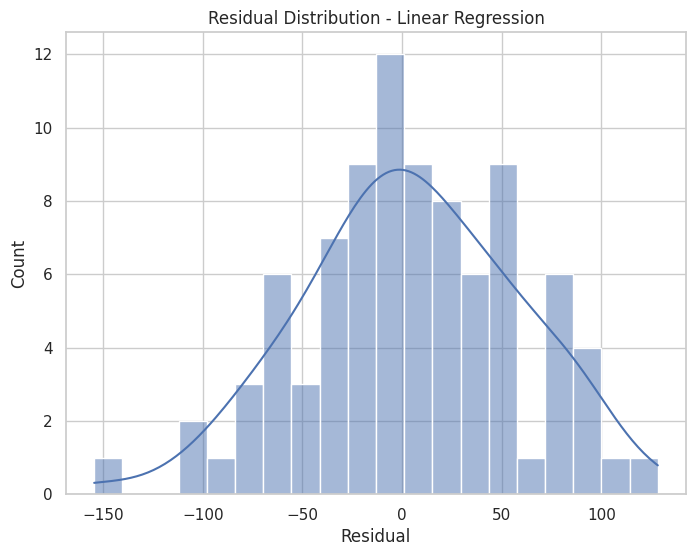

In [33]:
plt.figure(figsize=(8, 6))
sns.histplot(residuals_lr, bins=20, kde=True)
plt.xlabel("Residual")
plt.title("Residual Distribution - Linear Regression")
plt.show()

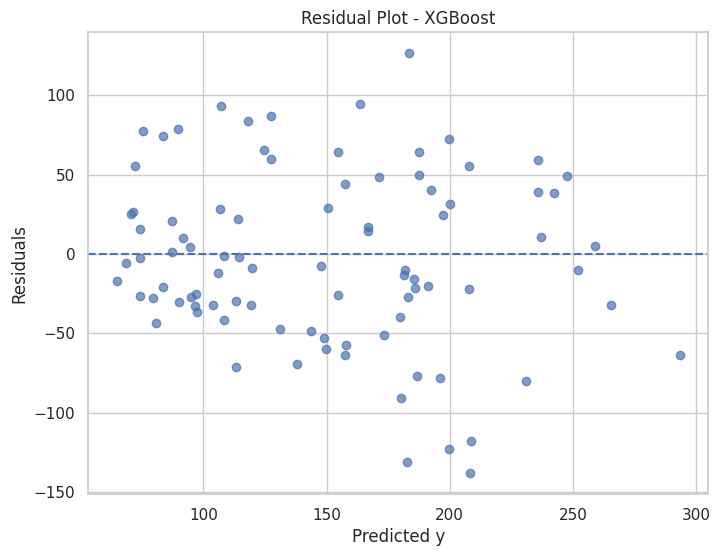

In [34]:
residuals_xgb = y_test - y_pred_xgb_test

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_xgb_test, residuals_xgb, alpha=0.7)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted y")
plt.ylabel("Residuals")
plt.title("Residual Plot - XGBoost")
plt.show()

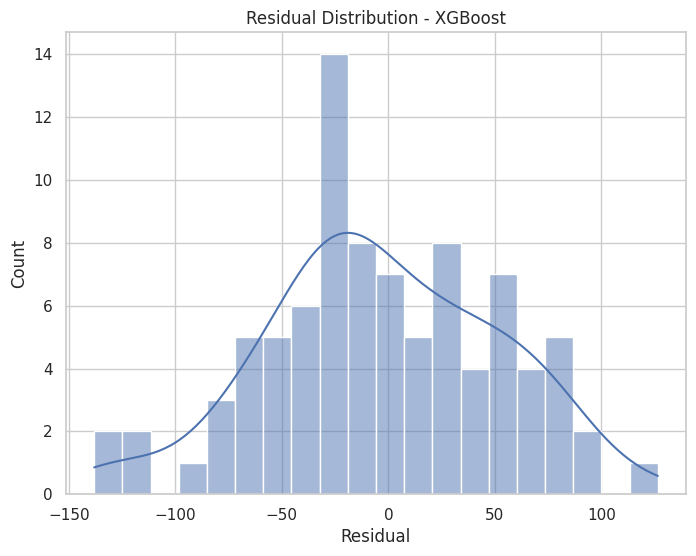

In [35]:
plt.figure(figsize=(8, 6))
sns.histplot(residuals_xgb, bins=20, kde=True)
plt.xlabel("Residual")
plt.title("Residual Distribution - XGBoost")
plt.show()

In [36]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_mse = -cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kf,
    scoring="neg_mean_squared_error"
)

lr_cv_r2 = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kf,
    scoring="r2"
)

pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Linear Regression CV MSE": lr_cv_mse,
    "Linear Regression CV R2": lr_cv_r2
})

,Fold,Linear Regression CV MSE,Linear Regression CV R2
0,1,2900.193628,0.452603
1,2,2662.637609,0.573200
2,3,3312.305889,0.391448
3,4,2797.883553,0.584289
4,5,3403.887793,0.390812


In [37]:
xgb_cv_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_cv_mse = -cross_val_score(
    xgb_cv_model,
    X,
    y,
    cv=kf,
    scoring="neg_mean_squared_error"
)

xgb_cv_r2 = cross_val_score(
    xgb_cv_model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "XGBoost CV MSE": xgb_cv_mse,
    "XGBoost CV R2": xgb_cv_r2
})

,Fold,XGBoost CV MSE,XGBoost CV R2
0,1,2959.455811,0.441417
1,2,2968.166016,0.524226
2,3,4107.070801,0.245430
3,4,3482.123535,0.482624
4,5,3233.653320,0.421278


In [38]:
cv_summary = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost"],
    "Mean CV MSE": [lr_cv_mse.mean(), xgb_cv_mse.mean()],
    "Std CV MSE": [lr_cv_mse.std(), xgb_cv_mse.std()],
    "Mean CV R2": [lr_cv_r2.mean(), xgb_cv_r2.mean()],
    "Std CV R2": [lr_cv_r2.std(), xgb_cv_r2.std()]
})

cv_summary

,Model,Mean CV MSE,Std CV MSE,Mean CV R2,Std CV R2
0,Linear Regression,3015.381694,291.239794,0.478470,0.084967
1,XGBoost,3350.093896,424.846157,0.422995,0.095577


In [39]:
final_summary = pd.DataFrame({
    "Model": ["Best Single Feature LR", "Best Pair LR", "All Features LR", "Linear Regression Test", "XGBoost Test"],
    "MSE": [
        best_single["MSE"],
        best_pair["MSE"],
        all_features_mse,
        lr_test_mse,
        xgb_test_mse
    ]
})

final_summary.sort_values(by="MSE")

,Model,MSE
2,All Features LR,2859.696348
3,Linear Regression Test,2900.193628
4,XGBoost Test,2959.456055
1,Best Pair LR,3205.190077
0,Best Single Feature LR,3890.456585


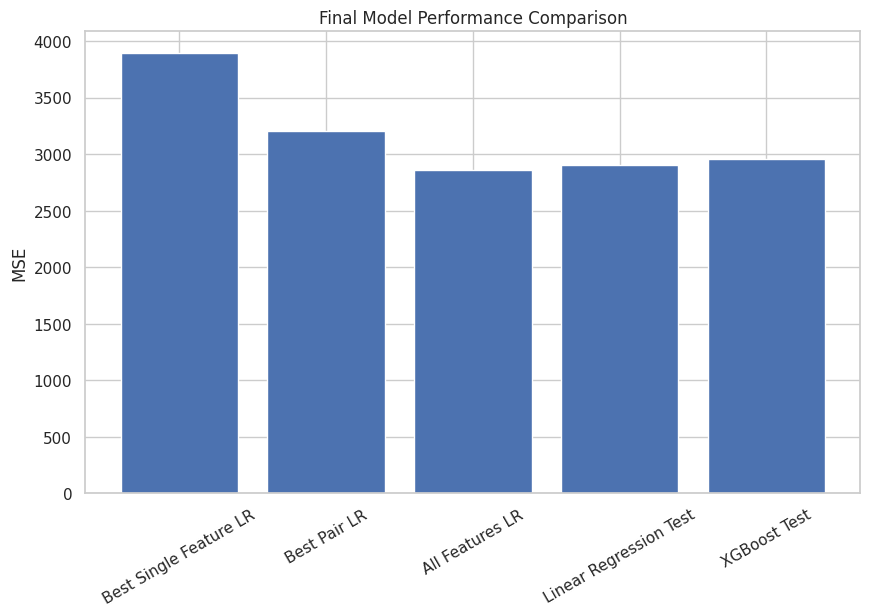

In [40]:
plt.figure(figsize=(10, 6))
plt.bar(final_summary["Model"], final_summary["MSE"])
plt.xticks(rotation=30)
plt.ylabel("MSE")
plt.title("Final Model Performance Comparison")
plt.show()